# Notebook pour charger le jeu sur VS Code

In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/prog_IceHockey

Mounted at /content/drive
/content/drive/MyDrive/prog_IceHockey


In [2]:
import os
import torch
device = 'GPU' if torch.cuda.is_available() else 'CPU'
print('Vous utilisez le {} '.format(device))

Vous utilisez le GPU 


In [3]:
import gymnasium as gym
import ale_py

print(f"Version de ALE: {ale_py.__version__}")

game_list = [spec for spec in gym.registry.keys() if 'IceHockey' in spec]
print(f"Jeux d'arcade disponibles: {game_list}")

Version de ALE: 0.11.2
Jeux d'arcade disponibles: ['IceHockey-v0', 'IceHockey-v4', 'IceHockeyNoFrameskip-v0', 'IceHockeyNoFrameskip-v4', 'ALE/IceHockey-v5']


In [4]:
!pip install -r requirements.txt

In [5]:
! AutoROM --accept-license

AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/usr/local/lib/python3.12/dist-packages/AutoROM/roms
	/usr/local/lib/python3.12/dist-packages/multi_agent_ale_py/roms

Existing ROMs will be overwritten.


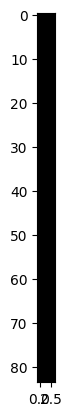

Forme finale de l'observation : (84, 84, 4)


In [6]:
import supersuit as ss
import matplotlib.pyplot as plt
from pettingzoo.atari import ice_hockey_v2

def get_env():
    # 1. Env de base
    env = ice_hockey_v2.env(render_mode="rgb_array")

    # 2. Réduction à 1 seul canal (Rouge) -> (210, 160, 1)
    env = ss.color_reduction_v0(env, mode='R')

    # 3. Redimensionnement -> (84, 84, 1)
    env = ss.resize_v1(env, x_size=84, y_size=84)

    # 4. On empile 4 images -> (84, 336, 1) ou (1, 84, 336) selon ta version
    env = ss.frame_stack_v1(env, 4)

    # 5. On convertit en float32
    env = ss.dtype_v0(env, 'float32')

    return env
# --- TEST DE VÉRIFICATION ---
env = get_env()
env.reset()
obs, reward, term, trunc, info = env.last()
plt.imshow(obs[0], cmap='gray')
plt.show()
print(f"Forme finale de l'observation : {obs.shape}")

In [7]:
import torch
import numpy as np
from pettingzoo.atari import ice_hockey_v2
from MAPOCA.actor import MultiAgentActors


# 1. Utilise ta fonction get_env() pour avoir les wrappers SuperSuit
env = get_env()
# Note : Si tu veux voir le jeu, change render_mode="human" dans get_env
# ou utilise render_mode="rgb_array" pour Colab.

env.reset()

max_steps = 5000
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

actor = MultiAgentActors(action_dim=18).to(device)

# On suppose que 'actor' est déjà initialisé et envoyé sur le device
actor.eval() # Mode évaluation

for i, agent in enumerate(env.agent_iter()):
    observation, reward, termination, truncation, info = env.last()

    if termination or truncation:
        action = None
    else:
        # --- AJUSTEMENT DES DIMENSIONS ---
        # observation est (84, 84, 4) -> on veut (4, 84, 84)
        obs_input = observation.transpose(2, 0, 1)

        # Conversion en tenseur [1, 4, 84, 84]
        obs_tensor = torch.from_numpy(obs_input).float().unsqueeze(0).to(device)

        with torch.no_grad():
            # Utilise get_action pour avoir une décision (déterministe pour la démo)
            action = actor.get_action(obs_tensor, deterministic=True).item()

    env.step(action)

    if i >= max_steps:
        print(f"Arrêt manuel après {max_steps} itérations.")
        break

env.close()
print("Démo terminée proprement !")

Arrêt manuel après 5000 itérations.
Démo terminée proprement !


Démarrage de la capture vidéo...
✅ Vidéo sauvegardée avec succès : demo_hockey.gif


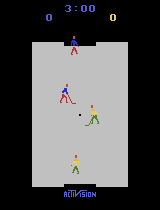

In [8]:
import PIL.Image
from IPython.display import display

import PIL.Image
from IPython.display import Image, display
import torch

# --- DÉFINITION ---
def record_video(env, actor, filename="demo_hockey.gif", device="cpu"):
    print("Démarrage de la capture vidéo...")
    env.reset()
    frames = []

    # On passe l'actor en mode évaluation
    actor.eval()

    for i, agent in enumerate(env.agent_iter()):
        obs, reward, terminated, truncated, info = env.last()

        # Capture du rendu AVANT de passer à l'étape suivante
        if i % 2 == 0:
            frame = env.render()
            if frame is not None:
                frames.append(PIL.Image.fromarray(frame))

        if terminated or truncated:
            action = None
        else:
            # Prétraitement (H, W, C) -> (C, H, W)
            obs_input = obs.transpose(2, 0, 1)
            obs_tensor = torch.from_numpy(obs_input).float().unsqueeze(0).to(device)

            with torch.no_grad():
                action = actor.get_action(obs_tensor, deterministic=True).item()

        env.step(action)

        if terminated or truncated or i > 1500: # Limite pour éviter un GIF trop lourd
            break

    if len(frames) > 0:
        # --- SAUVEGARDE ---
        frames[0].save(filename, save_all=True, append_images=frames[1:], duration=40, loop=0)
        print(f"✅ Vidéo sauvegardée avec succès : {filename}")
    else:
        print("❌ Erreur : Aucune frame n'a été capturée.")

# --- EXÉCUTION (L'appel manquant) ---
# Assure-toi que ton 'actor' et ton 'env' sont bien initialisés avant
record_video(env, actor, filename="demo_hockey.gif", device=device)

# --- VISUALISATION ---
display(Image(filename="demo_hockey.gif"))




In [ ]:
ls

# Exécution de MA-POCA

In [9]:
# importation des bibliothèques et des classes nécessaires

from MAPOCA.multi_agent_buffer import MultiAgentBuffer

buffer = MultiAgentBuffer()


Première version de collect_trajectories avec la récompense caclulée grâce à la mémoire RAM

In [10]:
import torch

def collect_trajectories(env, actor, buffer, max_steps=1000):

    "Cette fonction permet de récupérer les trajectoires des agents pendant les mille premières étapes du jeu"
    env.reset()

    # Initialisation des stockages temporaires par agent
    temp_obs = {}
    temp_acts = {}
    temp_logprobs = {}

    step_count = 0

    for agent in env.agent_iter():
        # 'info' est ignoré car non nécessaire pour la logique MA-POCA de base
        obs, reward, terminated, truncated, _ = env.last()

        ram = env.unwrapped.ale.getRAM()

        # Extraction des coordonnées
        ## =====ATTENTION: cette méthode consiste à lire les coordonnées à partir de la ======
        ## ===== mémoire RAM du processeur, je suis pas sûr que ce soit legit =======
        # Positions (selon les adresses Atari d'Ice Hockey)
        x_puck, y_puck = ram[54], ram[55]
        if agent == "first_0":
            x_j, y_j = ram[56], ram[57]
        else:
            x_j, y_j = ram[58], ram[59]

        # calcul de la distance_reward

        dist = np.sqrt((x_j - x_puck)**2 + (y_j - y_puck)**2)
        distance_reward = 1.0 / (dist + 1.0) # Max si dist=0

        # calcul de la angle_reward
        direction_reward = 0.1 if (x_puck > 100) else 0.0

        # calcul de la hit_reward

        hit_reward = reward * 50

        # pénalité de temps pour inciter les joueurs à marquer vite

        time_penalty = -0.01

        # pénalité si le palet est dans le camps des joueurs pour inciter les joueurs à attaquer le camp adverse

        defense_penalty =0
        if (agent == "first_0" and x_j < 30) or (agent == "second_0" and x_puck < 30):
            defense_penalty = -0.1

        # Mise en place de la reward mère

        global_reward = hit_reward + (distance_reward * 2.0) + direction_reward + time_penalty + defense_penalty

        done = terminated or truncated

        if done:
            action = None
            logp = 0
        else:
            # Conversion de l'observation (H, W, C) -> (1, C, H, W) pour le CNN
            # Note: Vérifie si ton Wrapper Supersuit a déjà mis les channels en premier
            obs_permu = obs.transpose(2, 0, 1)
            obs_tensor = torch.from_numpy(obs_permu).float().unsqueeze(0).to(device)

            with torch.no_grad():
                logits = actor(obs_tensor)
                dist = torch.distributions.Categorical(logits=logits)
                action_tensor = dist.sample()
                logp = dist.log_prob(action_tensor).item()
                action = action_tensor.item()

        env.step(action)

        # 1. Stockage de l'observation de l'agent actuel
        temp_obs[agent] = obs

        # 2. Stockage de l'action si le jeu n'est pas fini
        if action is not None:
            temp_acts[agent] = action
            temp_logprobs[agent] = logp

        # 3. Une fois que les DEUX agents ont agi (Fin du cycle temporel t)
        if len(temp_acts) == 2:
            # On récupère le dictionnaire complet des récompenses du pas t
            # 'env.rewards' contient {'first_0': r1, 'second_0': r2}
            team_reward = [global_reward, global_reward]

            buffer.add(
                observation=[temp_obs['first_0'], temp_obs['second_0']],
                action=[temp_acts['first_0'], temp_acts['second_0']],
                logprob=[temp_logprobs['first_0'], temp_logprobs['second_0']],
                reward=team_reward,
                done=done
            )

            # Reset des dictionnaires temporaires pour le prochain pas t+1
            temp_acts = {}
            temp_logprobs = {}
            step_count += 1

        if done or step_count >= max_steps:
            break

    return step_count

Test pour vérifier s'il voit bien le palet

2ème version de collect_trajectories avec la méthode extraction de caractéristiques visuelles

D'abord petit test pour vérifier qu'on arrive bien à visualiser le palet. ça va nous permettre ensuite de calculer la distance entre les joueurs et le palet.

Cible trouvée : (41, 41)


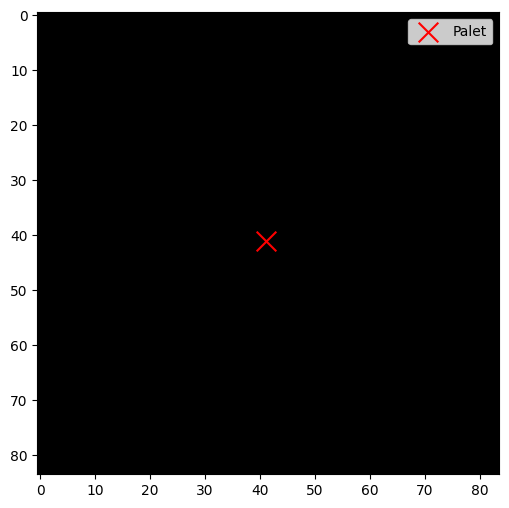

In [10]:
from MAPOCA.rewards_system import puck_position

import matplotlib.pyplot as plt

# 1. On récupère une image fraîche de l'environnement
detector = puck_position()

env.reset()
obs, _, _, _, _ = env.last()

# Pour l'affichage plt, on ne prend que la première couche de la pile
display_img = obs[:, :, 0] if obs.ndim == 3 else obs

coords = detector.get_puck_position(obs)

plt.figure(figsize=(6, 6))
plt.imshow(display_img, cmap='gray')

if coords:
    plt.scatter(coords[0], coords[1], s=200, c='red', marker='x', label="Palet")
    plt.legend()
    print(f"Cible trouvée : {coords}")
else:
    print("Palet non trouvé. Essaie de monter 'upper_black' à 60.")
plt.show()

In [ ]:
def collect_trajectories_v2(env, actor, buffer, max_steps=1000):
    "Cette fonction permet de récupérer les trajectoires des agents pendant les mille premières étapes du jeu"
    env.reset()
    detector = puck_position()

    # Initialisation des stockages temporaires par agent
    temp_obs = {}
    temp_acts = {}
    temp_logprobs = {}

    step_count = 0

    for agent in env.agent_iter():
        # 'info' est ignoré car non nécessaire pour la logique MA-POCA de base
        obs, reward, terminated, truncated, _ = env.last()

        ram = env.unwrapped.ale.getRAM()

        # Extraction des coordonnées
        ## ===== Ici on va utiliser
        x_puck, y_puck = ram[54], ram[55]
        if agent == "first_0":
            x_j, y_j = ram[56], ram[57]
        else:
            x_j, y_j = ram[58], ram[59]

        # calcul de la distance_reward

        dist = np.sqrt((x_j - x_puck)**2 + (y_j - y_puck)**2)
        distance_reward = 1.0 / (dist + 1.0) # Max si dist=0

        # calcul de la angle_reward
        direction_reward = 0.1 if (x_puck > 100) else 0.0

        # calcul de la hit_reward

        hit_reward = reward * 50

        # pénalité de temps pour inciter les joueurs à marquer vite

        time_penalty = -0.01

        # pénalité si le palet est dans le camps des joueurs pour inciter les joueurs à attaquer le camp adverse

        defense_penalty =0
        if (agent == "first_0" and x_j < 30) or (agent == "second_0" and x_puck < 30):
            defense_penalty = -0.1

        # Mise en place de la reward mère

        global_reward = hit_reward + (distance_reward * 2.0) + direction_reward + time_penalty + defense_penalty

        done = terminated or truncated

        if done:
            action = None
            logp = 0
        else:
            # Conversion de l'observation (H, W, C) -> (1, C, H, W) pour le CNN
            # Note: Vérifie si ton Wrapper Supersuit a déjà mis les channels en premier
            obs_permu = obs.transpose(2, 0, 1)
            obs_tensor = torch.from_numpy(obs_permu).float().unsqueeze(0).to(device)

            with torch.no_grad():
                logits = actor(obs_tensor)
                dist = torch.distributions.Categorical(logits=logits)
                action_tensor = dist.sample()
                logp = dist.log_prob(action_tensor).item()
                action = action_tensor.item()

        env.step(action)

        # 1. Stockage de l'observation de l'agent actuel
        temp_obs[agent] = obs

        # 2. Stockage de l'action si le jeu n'est pas fini
        if action is not None:
            temp_acts[agent] = action
            temp_logprobs[agent] = logp

        # 3. Une fois que les DEUX agents ont agi (Fin du cycle temporel t)
        if len(temp_acts) == 2:
            # On récupère le dictionnaire complet des récompenses du pas t
            # 'env.rewards' contient {'first_0': r1, 'second_0': r2}
            team_reward = [global_reward, global_reward]

            buffer.add(
                observation=[temp_obs['first_0'], temp_obs['second_0']],
                action=[temp_acts['first_0'], temp_acts['second_0']],
                logprob=[temp_logprobs['first_0'], temp_logprobs['second_0']],
                reward=team_reward,
                done=done
            )

            # Reset des dictionnaires temporaires pour le prochain pas t+1
            temp_acts = {}
            temp_logprobs = {}
            step_count += 1

        if done or step_count >= max_steps:
            break

    return step_count


Suite du programme

In [11]:
def compute_returns_lambda(rewards, values, next_value, dones, gamma=0.99, lmbda = 0.95):
    "Calcule G_t^(lambda) pour un agent"

    returns = torch.zeros_like(rewards)
    gae = 0

    for t in reversed(range(len(rewards))):
        if t == len(rewards) -1:
            next_non_terminal = 1.0 - dones[t]
            next_val = next_value
        else:
            next_non_terminal = 1.0 - dones[t+1]
            next_val = values[t+1]

        # TD Error (delta)
        delta = rewards[t] + gamma * next_val * next_non_terminal - values[t]

        # GAE (Generalized Advantage Estimation) qui est équivalent au TD(lambda)
        gae = delta + gamma * lmbda * next_non_terminal * gae

        returns[t] = gae + values[t]

    return returns


In [12]:
def prepare_targets(buffer, critic, gamma=0.99, lmbda = 0.95):
    obs_ag1 = torch.stack([torch.from_numpy(o[0]) for o in buffer.observations]).float()
    obs_ag2 = torch.stack([torch.from_numpy(o[1]) for o in buffer.observations]).float()

    rewards = torch.tensor(buffer.rewards).float()  # Shape: (N, 2)
    dones = torch.tensor(buffer.dones).float()      # Shape: (N,)

    #2. ici on cherche à obtenir les valeurs V du critic centralisé

    with torch.no_grad():
        values = critic([obs_ag1, obs_ag2])  # Shape: (N, 2)

        next_value = torch.zeros(2)

    all_returns = []
    all_advantages = []
    for i in range(2):
        ret = compute_returns_lambda(
            rewards[:, i], values[:, i], next_value[i], dones, gamma, lmbda
        )
        advantage = ret - values[:, i]
        all_returns.append(ret)
        all_advantages.append(advantage)


    return torch.stack(all_returns, dim=1), torch.stack(all_advantages, dim=1)

In [13]:
def update_mapoca(actor, critic, buffer, optimizer_actor, optimizer_critic):
    #1. Préparation des données

    returns, advantages = prepare_targets(buffer, critic)

    #2. on applatit ensuite les dimensions pour le calcul de la perte

    obs_ag1 = torch.stack([torch.from_numpy(o[0]) for o in buffer.observations]).float()
    obs_ag2 = torch.stack([torch.from_numpy(o[1]) for o in buffer.observations]).float()
    actions = torch.tensor(buffer.actions)  # Shape: (N, 2)
    old_logprobs = torch.tensor(buffer.logprobs)  # Shape: (N, 2)

    #3. Mise à jour du critic centralisé

    current_values = critic([obs_ag1, obs_ag2])  # Shape: (N, 2)
    critic_loss = torch.nn.MSELoss()(current_values, returns)

    # 4. Mise à jour de l'actor

    # pour l'agent 1
    logits1 = actor(obs_ag1)  # Shape: (N, action_dim)
    dist1 = torch.distributions.Categorical(logits=logits1)
    new_logprob1 = dist1.log_prob(actions[:, 0])  # Log-prob de l'action prise par agent 1

    # pour l'agent 2

    logits2 = actor(obs_ag2)  # Shape: (N, action_dim)
    dist2 = torch.distributions.Categorical(logits=logits2)
    new_logprob2 = dist2.log_prob(actions[:, 1])  # Log-prob de l'action prise par agent 2

    # Calcul de la perte Policy Gradient pour les deux agents

    actor_loss = -(new_logprob1 * advantages[:, 0]).mean() - (new_logprob2 * advantages[:, 1]).mean()

    # Ajout de l'entropie pour encourager l'exploration

    entropy = dist1.entropy().mean() + dist2.entropy().mean()
    total_actor_loss = actor_loss - 0.01 * entropy

    optimizer_actor.zero_grad()
    total_actor_loss.backward()
    optimizer_actor.step()

    return critic_loss.item(), actor_loss.item()



On vérifie ce que les joueurs font

## Exécution de la boucle principale

  0%|          | 0/5000 [00:00<?, ?it/s]/tmp/ipykernel_15612/500894598.py:33: RuntimeWarning: overflow encountered in scalar subtract
  dist = np.sqrt((x_j - x_puck)**2 + (y_j - y_puck)**2)
/tmp/ipykernel_15612/500894598.py:33: RuntimeWarning: overflow encountered in scalar add
  dist = np.sqrt((x_j - x_puck)**2 + (y_j - y_puck)**2)
  0%|          | 1/5000 [00:02<2:51:36,  2.06s/it]

 Episode 0 | Score Moyen: 0.3803 | Loss Critic: 8.0234e+00


  0%|          | 11/5000 [00:13<1:30:53,  1.09s/it]

 Episode 10 | Score Moyen: 0.4074 | Loss Critic: 5.1248e+00


  0%|          | 21/5000 [00:24<1:32:25,  1.11s/it]

...

100%|█████████▉| 4981/5000 [1:31:58<00:22,  1.20s/it]

 Episode 4980 | Score Moyen: 0.3991 | Loss Critic: 3.1208e-01


100%|█████████▉| 4991/5000 [1:32:09<00:09,  1.04s/it]

 Episode 4990 | Score Moyen: 0.3879 | Loss Critic: 4.8322e-01


100%|██████████| 5000/5000 [1:32:19<00:00,  1.11s/it]


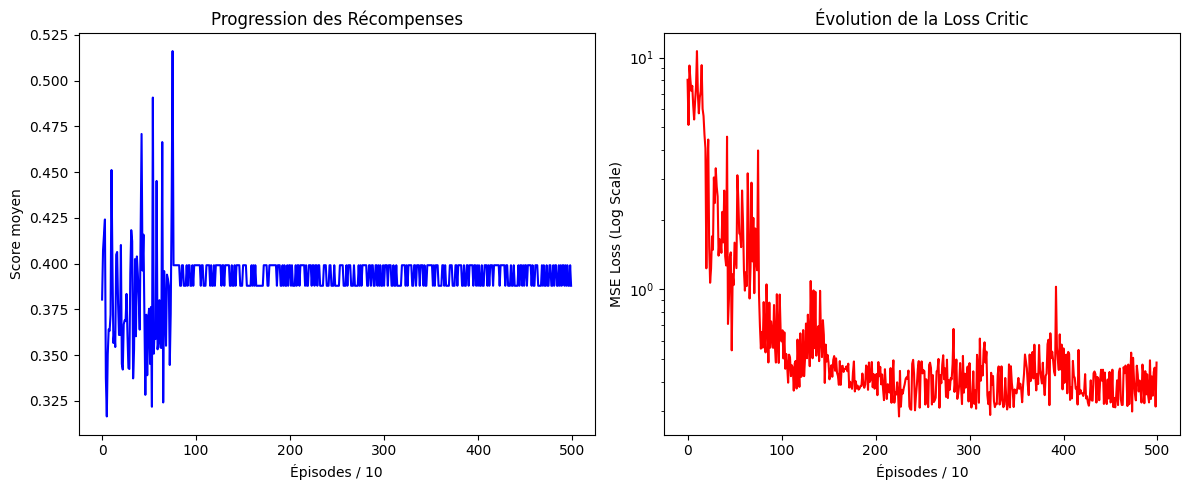

In [14]:
#importation des bibliothèques

import torch
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# importation des modules

from MAPOCA.multi_agent_buffer import MultiAgentBuffer
from MAPOCA.centralized_critic import Centralized_critic
from MAPOCA.actor import MultiAgentActors
from MAPOCA.observation_encoding import Impala_CNN, Impala_Layer
from MAPOCA.RSA import RSAModule

# Hyperparamètres
LR_ACTOR = 1e-4
LR_CRITIC = 3e-4
GAMMA = 0.99
LMBDA = 0.95
BATCH_SIZE = 128  # Nombre de pas de temps par mise à jour
TOTAL_EPISODES = 5000

actor = MultiAgentActors(action_dim = 18).to(device)
critic = Centralized_critic(num_agents=2).to(device)

optimizer_actor = optim.Adam(actor.parameters(), lr=LR_ACTOR)
optimizer_critic = optim.Adam(critic.parameters(), lr=LR_CRITIC)

buffer = MultiAgentBuffer()

# Boucle principale

rewards_history = []
critic_losses_history = []
dist_history = []

for episode in tqdm(range(TOTAL_EPISODES)):
    # On modifie collect_trajectories pour qu'elle retourne aussi la distance moyenne
    step_count = collect_trajectories(env, actor, buffer, max_steps=BATCH_SIZE)

    if len(buffer.observations) >= BATCH_SIZE:
        # 1. Préparation des tenseurs (permute inclus)
        obs_raw_1 = torch.stack([torch.from_numpy(o[0]) for o in buffer.observations]).float()
        obs_raw_2 = torch.stack([torch.from_numpy(o[1]) for o in buffer.observations]).float()
        obs_ag1 = obs_raw_1.permute(0, 3, 1, 2).to(device)
        obs_ag2 = obs_raw_2.permute(0, 3, 1, 2).to(device)

        rewards = torch.tensor(buffer.rewards).float().to(device)
        dones = torch.tensor(buffer.dones).float().to(device)
        actions = torch.tensor(buffer.actions).to(device)

        # 2. Calcul des Valeurs et Retours
        with torch.no_grad():
            values = critic([obs_ag1, obs_ag2]) # (Batch, 2)
            next_value = torch.zeros(2).to(device)

            all_returns = []
            for i in range(2):
                ret = compute_returns_lambda(rewards[:, i], values[:, i], next_value[i], dones, GAMMA, LMBDA)
                all_returns.append(ret)

            returns = torch.stack(all_returns, dim=1)
            # Important : Advantage se calcule avec les valeurs détachées du gradient
            advantages = returns - values

        # 3. Mise à jour du Critic
        current_values = critic([obs_ag1, obs_ag2])
        critic_loss = F.mse_loss(current_values, returns)
        optimizer_critic.zero_grad()
        critic_loss.backward()
        optimizer_critic.step()

        # 4. Mise à jour de l'Actor
        logits1 = actor(obs_ag1)
        logp1 = torch.distributions.Categorical(logits=logits1).log_prob(actions[:, 0])

        logits2 = actor(obs_ag2)
        logp2 = torch.distributions.Categorical(logits=logits2).log_prob(actions[:, 1])

        # MA-POCA Loss (on utilise les avantages calculés par le critique centralisé)
        actor_loss = -(logp1 * advantages[:, 0]).mean() - (logp2 * advantages[:, 1]).mean()

        optimizer_actor.zero_grad()
        actor_loss.backward()
        optimizer_actor.step()

        # Affichage (Somme des rewards sur le batch / nombre d'agents)
        avg_reward = rewards.sum().item() / BATCH_SIZE
        if episode % 10 == 0:
            rewards_history.append(avg_reward)
            critic_losses_history.append(critic_loss.item())
            print(f" Episode {episode} | Score Moyen: {avg_reward:.4f} | Loss Critic: {critic_loss.item():.4e}")

        buffer.clear()

# 5. Visualisation double
plt.figure(figsize=(12, 5))

# Graphique des Récompenses
plt.subplot(1, 2, 1)
plt.plot(rewards_history, color='blue')
plt.title("Progression des Récompenses")
plt.xlabel("Épisodes / 10")
plt.ylabel("Score moyen")

# Graphique de la Loss du Critic
plt.subplot(1, 2, 2)
plt.plot(critic_losses_history, color='red')
plt.yscale('log') # Utilisation d'une échelle log car la loss peut varier brutalement
plt.title("Évolution de la Loss Critic")
plt.xlabel("Épisodes / 10")
plt.ylabel("MSE Loss (Log Scale)")

plt.tight_layout()
plt.show()



A exécuter après avoir exécuté le bloc de la boucle principale. Le bloc suivant permet de voir comment les joueurs se comportent après exécution de MA-POCA

In [ ]:
# Appel de la fonction de visualisation
# On utilise l'actor après quelques épisodes d'entraînement
record_video(env, actor, filename="evolution_poca.gif", device=device)

# Visualisation immédiate
from IPython.display import Image, display
display(Image(filename="evolution_poca.gif"))